# Principal Flood/Ebb Direction Calculation
This notebook computes principal tidal flow directions from `depthAvg_ADCPdata.csv` using doubled-angle averaging for bidirectional flows.

## Method
For directional samples $\theta$, the principal direction is estimated as:
$$\theta_{principal} = \frac{1}{2}\operatorname{atan2}(\langle\sin(2\theta)\rangle, \langle\cos(2\theta)\rangle)$$
Workflow used here:
1. Compute an overall principal axis from the full record.
2. Project velocity onto that axis to separate flood and ebb (using streamwise sign).
3. Recompute principal direction separately for flood and ebb subsets.
4. In this site convention, ENE is flow toward shore and is flood, while WSW is toward water and is ebb.

In [38]:
import numpy as np
import pandas as pd

CSV_PATH = 'depthAvg_ADCPdata.csv'
SLACK_THRESHOLD = 0.4  # m/s - equal to cut in speed

def principal_direction_deg(theta_deg):
    th = np.deg2rad(np.asarray(theta_deg, dtype=float))
    th = th[np.isfinite(th)]
    if th.size == 0:
        return np.nan
    s = np.mean(np.sin(2.0 * th))
    c = np.mean(np.cos(2.0 * th))
    return float(np.rad2deg(0.5 * np.arctan2(s, c)) % 360.0)

def wrap_deg(x):
    return np.asarray(x, dtype=float) % 360.0

def bearing_from_east_north(east, north):
    # Compass bearing clockwise from North
    return (np.rad2deg(np.arctan2(east, north)) + 360.0) % 360.0

def along_velocity(east, north, bearing_deg):
    phi = np.deg2rad(bearing_deg)
    return east * np.sin(phi) + north * np.cos(phi)

In [39]:
df = pd.read_csv(CSV_PATH)

required = ['Eas', 'Nor']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}. Available: {list(df.columns)}')

MMPS_TO_MPS = 1e-3
east = pd.to_numeric(df['Eas'], errors='coerce').to_numpy() * MMPS_TO_MPS
north = pd.to_numeric(df['Nor'], errors='coerce').to_numpy() * MMPS_TO_MPS

if 'Dir' in df.columns:
    theta = pd.to_numeric(df['Dir'], errors='coerce').to_numpy()
else:
    theta = bearing_from_east_north(east, north)

valid = np.isfinite(east) & np.isfinite(north) & np.isfinite(theta)
east_v = east[valid] 
north_v = north[valid] 
theta_v = wrap_deg(theta[valid])

overall_principal = principal_direction_deg(theta_v)
u_along = along_velocity(east_v, north_v, overall_principal)

# Positive streamwise velocity points toward water (ebb); negative points toward shore (flood).
is_ebb = u_along > SLACK_THRESHOLD
is_flood = u_along < -SLACK_THRESHOLD

flood_principal = principal_direction_deg(theta_v[is_flood])
ebb_principal = principal_direction_deg(theta_v[is_ebb])

summary = pd.DataFrame({
    'metric': [
        'samples_total',
        'samples_flood',
        'samples_ebb',
        'slack_threshold_mps',
        'overall_principal_degT',
        'flood_principal_degT',
        'ebb_principal_degT'
    ],
    'value': [
        int(theta_v.size),
        int(is_flood.sum()),
        int(is_ebb.sum()),
        float(SLACK_THRESHOLD),
        float(overall_principal),
        float(flood_principal),
        float(ebb_principal)
    ]
})

summary

,metric,value
0,samples_total,16542.000000
1,samples_flood,6483.000000
2,samples_ebb,6267.000000
3,slack_threshold_mps,0.400000
4,overall_principal_degT,75.054047
5,flood_principal_degT,76.520428
6,ebb_principal_degT,73.990981


In [40]:
# Optional: save classification and streamwise velocity for downstream use
out = df.copy()
out['Eas'] = pd.to_numeric(out['Eas'], errors='coerce') * MMPS_TO_MPS
out['Nor'] = pd.to_numeric(out['Nor'], errors='coerce') * MMPS_TO_MPS
if 'Mag' in out.columns:
    out['Mag'] = pd.to_numeric(out['Mag'], errors='coerce') * MMPS_TO_MPS
out['theta_used_degT'] = np.nan
out.loc[valid, 'theta_used_degT'] = theta_v
out['u_along_overall'] = np.nan
out.loc[valid, 'u_along_overall'] = u_along
out['phase'] = 'slack'
out.loc[valid, 'phase'] = np.where(is_flood, 'flood', np.where(is_ebb, 'ebb', 'slack'))

OUT_CSV = 'depthAvg_ADCPdata_labeled.csv'
out.to_csv(OUT_CSV, index=False)
OUT_CSV

'depthAvg_ADCPdata_labeled.csv'

## Depth-Profile Turbine-Relevant Metrics
This section reports: (1) peak speeds from depth profiles, (2) Reynolds number range, and (3) durations above minimum turbine operating speed.

In [41]:
DEPTH_PROFILE_CSV = 'depthDep_ADCPdata.csv'
MIN_TURBINE_SPEED_MPS = SLACK_THRESHOLD
KINEMATIC_VISCOSITY_M2PS = 1.19e-6  # seawater nu (~35 PSU, ~15 C)
CHAR_LENGTH_M = 32.1177  # set to turbine characteristic length for project-specific Re

prof = pd.read_csv(DEPTH_PROFILE_CSV, header=[0, 1])
date_col = next(c for c in prof.columns if str(c[0]).strip() == 'DateTime')
time_prof = pd.to_datetime(prof[date_col], errors='coerce')

mag_cols = [c for c in prof.columns if str(c[1]).strip() == 'Mag']
if not mag_cols:
    raise ValueError('No depth-profile Mag columns found in depthDep_ADCPdata.csv')
eas_cols = [c for c in prof.columns if str(c[1]).strip() == 'Eas']
nor_cols = [c for c in prof.columns if str(c[1]).strip() == 'Nor']
if not eas_cols or not nor_cols:
    raise ValueError('No depth-profile Eas/Nor columns found in depthDep_ADCPdata.csv')

mag_mmps = prof[mag_cols].apply(pd.to_numeric, errors='coerce')
mag_mps = mag_mmps * MMPS_TO_MPS
eas_mps = prof[eas_cols].apply(pd.to_numeric, errors='coerce') * MMPS_TO_MPS
nor_mps = prof[nor_cols].apply(pd.to_numeric, errors='coerce') * MMPS_TO_MPS
profile_peak_mps = mag_mps.max(axis=1, skipna=True)
profile_mean_mps = mag_mps.mean(axis=1, skipna=True)
u_along_profile = along_velocity(eas_mps.mean(axis=1, skipna=True), nor_mps.mean(axis=1, skipna=True), overall_principal)
phase_profile = np.where(u_along_profile > SLACK_THRESHOLD, 'ebb', np.where(u_along_profile < -SLACK_THRESHOLD, 'flood', 'slack'))
is_flood_prof = phase_profile == 'flood'
is_ebb_prof = phase_profile == 'ebb'

re_all = (mag_mps.to_numpy().ravel() * CHAR_LENGTH_M) / KINEMATIC_VISCOSITY_M2PS
re_all = re_all[np.isfinite(re_all) & (re_all > 0.0)]
re_flood = (mag_mps.loc[is_flood_prof].to_numpy().ravel() * CHAR_LENGTH_M) / KINEMATIC_VISCOSITY_M2PS
re_flood = re_flood[np.isfinite(re_flood) & (re_flood > 0.0)]
re_ebb = (mag_mps.loc[is_ebb_prof].to_numpy().ravel() * CHAR_LENGTH_M) / KINEMATIC_VISCOSITY_M2PS
re_ebb = re_ebb[np.isfinite(re_ebb) & (re_ebb > 0.0)]

bin_peak_mps = mag_mps.max(axis=0, skipna=True)
bin_peak_table = pd.DataFrame({
    'bin': [str(c[0]) for c in bin_peak_mps.index],
    'peak_speed_mps': bin_peak_mps.to_numpy()
}).sort_values('peak_speed_mps', ascending=False).reset_index(drop=True)

profile_metrics = pd.DataFrame({
    'metric': [
        'peak_profile_speed_mps',
        'peak_depth_mean_speed_mps',
        'peak_profile_speed_flood_mps',
        'peak_profile_speed_ebb_mps',
        'peak_depth_mean_speed_flood_mps',
        'peak_depth_mean_speed_ebb_mps',
        'profiles_flood',
        'profiles_ebb',
        'reynolds_flood_min',
        'reynolds_flood_max',
        'reynolds_ebb_min',
        'reynolds_ebb_max',
        'reynolds_min',
        'reynolds_max'
    ],
    'value': [
        float(profile_peak_mps.max(skipna=True)),
        float(profile_mean_mps.max(skipna=True)),
        float(profile_peak_mps[is_flood_prof].max(skipna=True)) if np.any(is_flood_prof) else np.nan,
        float(profile_peak_mps[is_ebb_prof].max(skipna=True)) if np.any(is_ebb_prof) else np.nan,
        float(profile_mean_mps[is_flood_prof].max(skipna=True)) if np.any(is_flood_prof) else np.nan,
        float(profile_mean_mps[is_ebb_prof].max(skipna=True)) if np.any(is_ebb_prof) else np.nan,
        int(np.sum(phase_profile == 'flood')),
        int(np.sum(phase_profile == 'ebb')),
        float(np.min(re_flood)) if re_flood.size else np.nan,
        float(np.max(re_flood)) if re_flood.size else np.nan,
        float(np.min(re_ebb)) if re_ebb.size else np.nan,
        float(np.max(re_ebb)) if re_ebb.size else np.nan,
        float(np.min(re_all)) if re_all.size else np.nan,
        float(np.max(re_all)) if re_all.size else np.nan
    ]
})

profile_metrics

,metric,value
0,peak_profile_speed_mps,1.702000e+00
1,peak_depth_mean_speed_mps,1.573766e+00
2,peak_profile_speed_flood_mps,1.702000e+00
3,peak_profile_speed_ebb_mps,1.669000e+00
4,peak_depth_mean_speed_flood_mps,1.573766e+00
5,peak_depth_mean_speed_ebb_mps,1.499458e+00
6,profiles_flood,6.482000e+03
7,profiles_ebb,6.265000e+03
8,reynolds_flood_min,1.889276e+06
9,reynolds_flood_max,4.593641e+07


In [44]:
valid_t = time_prof.dropna().sort_values()
if valid_t.size < 2:
    raise ValueError('Not enough valid timestamps in depth profile data to estimate duration')

dt_seconds = float(np.median(np.diff(valid_t.values).astype('timedelta64[s]').astype(float)))
if not np.isfinite(dt_seconds) or dt_seconds <= 0:
    raise ValueError('Could not determine a positive sampling interval from timestamps')

n_total = int(np.sum(np.isfinite(profile_peak_mps.to_numpy())))
n_flood = int(np.sum(phase_profile == 'flood'))
n_ebb = int(np.sum(phase_profile == 'ebb'))

n_peak_flood_exc = int(((profile_peak_mps >= MIN_TURBINE_SPEED_MPS) & (phase_profile == 'flood')).sum())
n_peak_ebb_exc = int(((profile_peak_mps >= MIN_TURBINE_SPEED_MPS) & (phase_profile == 'ebb')).sum())
n_mean_flood_exc = int(((profile_mean_mps >= MIN_TURBINE_SPEED_MPS) & (phase_profile == 'flood')).sum())
n_mean_ebb_exc = int(((profile_mean_mps >= MIN_TURBINE_SPEED_MPS) & (phase_profile == 'ebb')).sum())

pct_peak_flood_total = float(100.0 * n_peak_flood_exc / n_total) if n_total else np.nan
pct_peak_ebb_total = float(100.0 * n_peak_ebb_exc / n_total) if n_total else np.nan
pct_mean_flood_total = float(100.0 * n_mean_flood_exc / n_total) if n_total else np.nan
pct_mean_ebb_total = float(100.0 * n_mean_ebb_exc / n_total) if n_total else np.nan

duration_summary = pd.DataFrame({
    'metric': [
        'min_turbine_speed_mps',
        'sampling_interval_s',
        'samples_total_profiles',
        'samples_flood_profiles',
        'samples_ebb_profiles',
        'pct_peak_profile_above_0p4_flood_of_total',
        'pct_peak_profile_above_0p4_ebb_of_total',
        'pct_depth_mean_above_0p4_flood_of_total',
        'pct_depth_mean_above_0p4_ebb_of_total'
    ],
    'value': [
        float(MIN_TURBINE_SPEED_MPS),
        dt_seconds,
        n_total,
        n_flood,
        n_ebb,
        pct_peak_flood_total,
        pct_peak_ebb_total,
        pct_mean_flood_total,
        pct_mean_ebb_total
    ]
})

duration_summary

,metric,value
0,min_turbine_speed_mps,0.400000
1,sampling_interval_s,600.000000
2,samples_total_profiles,16542.000000
3,samples_flood_profiles,6482.000000
4,samples_ebb_profiles,6265.000000
5,pct_peak_profile_above_0p4_flood_of_total,39.185105
6,pct_peak_profile_above_0p4_ebb_of_total,37.873292
7,pct_depth_mean_above_0p4_flood_of_total,39.185105
8,pct_depth_mean_above_0p4_ebb_of_total,37.873292


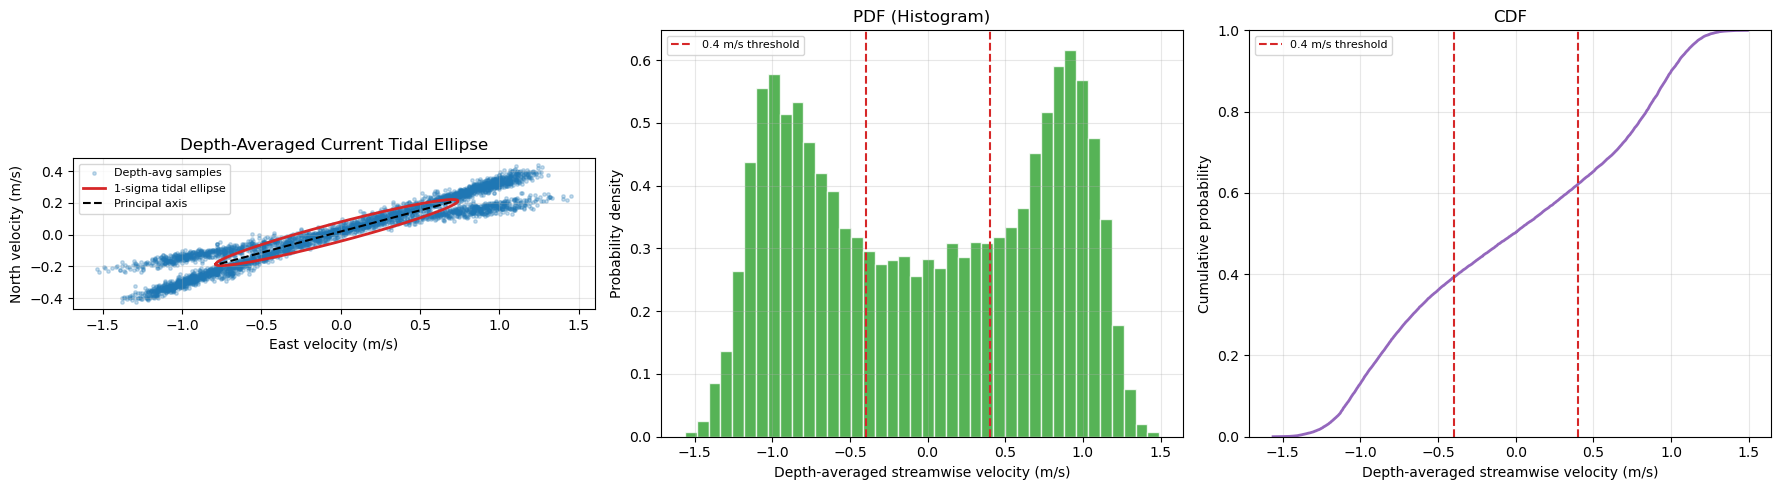

In [45]:
import matplotlib.pyplot as plt

# Depth-averaged tidal ellipse from east/north velocity covariance
vel = np.column_stack([east_v, north_v])
vel = vel[np.all(np.isfinite(vel), axis=1)]
if vel.shape[0] < 3:
    raise ValueError('Not enough valid depth-averaged velocity samples for tidal ellipse')

mu = vel.mean(axis=0)
cov = np.cov(vel[:, 0], vel[:, 1])
evals, evecs = np.linalg.eigh(cov)
order = np.argsort(evals)[::-1]
evals = evals[order]
evecs = evecs[:, order]

t = np.linspace(0.0, 2.0 * np.pi, 361)
unit_circle = np.vstack((np.cos(t), np.sin(t)))
ellipse = (evecs @ np.diag(np.sqrt(np.maximum(evals, 0.0))) @ unit_circle).T + mu

u = np.asarray(u_along, dtype=float)
u = u[np.isfinite(u)]
if u.size < 3:
    raise ValueError('Not enough valid streamwise samples for PDF/CDF')

u_sorted = np.sort(u)
cdf = np.arange(1, u_sorted.size + 1, dtype=float) / u_sorted.size

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax0 = axes[0]
n_plot = min(4000, vel.shape[0])
idx = np.linspace(0, vel.shape[0] - 1, n_plot, dtype=int)
ax0.scatter(vel[idx, 0], vel[idx, 1], s=6, alpha=0.25, color='tab:blue', label='Depth-avg samples')
ax0.plot(ellipse[:, 0], ellipse[:, 1], color='tab:red', lw=2.0, label='1-sigma tidal ellipse')

phi = np.deg2rad(overall_principal)
axis_len = np.nanmax(np.abs(ellipse - mu))
ax0.plot([mu[0] - axis_len * np.sin(phi), mu[0] + axis_len * np.sin(phi)], [mu[1] - axis_len * np.cos(phi), mu[1] + axis_len * np.cos(phi)], 'k--', lw=1.5, label='Principal axis')
ax0.set_xlabel('East velocity (m/s)')
ax0.set_ylabel('North velocity (m/s)')
ax0.set_title('Depth-Averaged Current Tidal Ellipse')
ax0.set_aspect('equal', adjustable='box')
ax0.grid(alpha=0.3)
ax0.legend(loc='best', fontsize=8)

ax1 = axes[1]
ax1.hist(u, bins=40, density=True, color='tab:green', alpha=0.8, edgecolor='white')
ax1.axvline(MIN_TURBINE_SPEED_MPS, color='tab:red', ls='--', lw=1.5, label='0.4 m/s threshold')
ax1.axvline(-MIN_TURBINE_SPEED_MPS, color='tab:red', ls='--', lw=1.5)
ax1.set_xlabel('Depth-averaged streamwise velocity (m/s)')
ax1.set_ylabel('Probability density')
ax1.set_title('PDF (Histogram)')
ax1.grid(alpha=0.3)
ax1.legend(loc='best', fontsize=8)

ax2 = axes[2]
ax2.plot(u_sorted, cdf, color='tab:purple', lw=2.0)
ax2.axvline(MIN_TURBINE_SPEED_MPS, color='tab:red', ls='--', lw=1.5, label='0.4 m/s threshold')
ax2.axvline(-MIN_TURBINE_SPEED_MPS, color='tab:red', ls='--', lw=1.5)
ax2.set_xlabel('Depth-averaged streamwise velocity (m/s)')
ax2.set_ylabel('Cumulative probability')
ax2.set_title('CDF')
ax2.set_ylim(0.0, 1.0)
ax2.grid(alpha=0.3)
ax2.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()